# Modeling — Credit Card Fraud Detection

Compares a class-weighted Logistic Regression baseline, a SMOTE-resampled
Logistic Regression, and a class-weighted XGBoost model. Picks a winner and
an operating threshold, matching Phase 3 of PRD.md.

Never report plain accuracy — this dataset is ~0.17% fraud. Metrics below
are PR-AUC, precision, recall, F1, and the confusion matrix, all on a
held-out test set that keeps the real class imbalance intact.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

from src.data import load_data, split_data
from src.train import train_logistic_baseline, train_logistic_smote, train_xgboost
from src.evaluate import evaluate, best_threshold_for_f1

sns.set_theme(style="whitegrid")

In [2]:
df = load_data()
X_train, X_test, y_train, y_test = split_data(df)
X_train.shape, X_test.shape, y_train.sum(), y_test.sum()

((227845, 30), (56962, 30), np.int64(394), np.int64(98))

## Train the three candidates

In [3]:
baseline = train_logistic_baseline(X_train, y_train)
smote_model = train_logistic_smote(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

## Compare at default threshold (0.5)

In [4]:
results = {
    "logreg_class_weighted": evaluate(baseline, X_test, y_test),
    "logreg_smote": evaluate(smote_model, X_test, y_test),
    "xgboost_class_weighted": evaluate(xgb_model, X_test, y_test),
}

comparison = pd.DataFrame(results).T[["pr_auc", "precision", "recall", "f1"]]
comparison

,pr_auc,precision,recall,f1
logreg_class_weighted,0.718971,0.060976,0.918367,0.114358
logreg_smote,0.724469,0.057803,0.918367,0.108761
xgboost_class_weighted,0.853419,0.625954,0.836735,0.716157


## Decision

Pick the model with the best PR-AUC (threshold-independent) as the winner;
SMOTE is a comparison point, not the default — see `src/train.py` docstring
for why class weighting is the shipped strategy.

In [5]:
winner_name = comparison["pr_auc"].idxmax()
winner = {"logreg_class_weighted": baseline, "logreg_smote": smote_model, "xgboost_class_weighted": xgb_model}[winner_name]
winner_name

'xgboost_class_weighted'

## Precision-recall tradeoff for the winning model

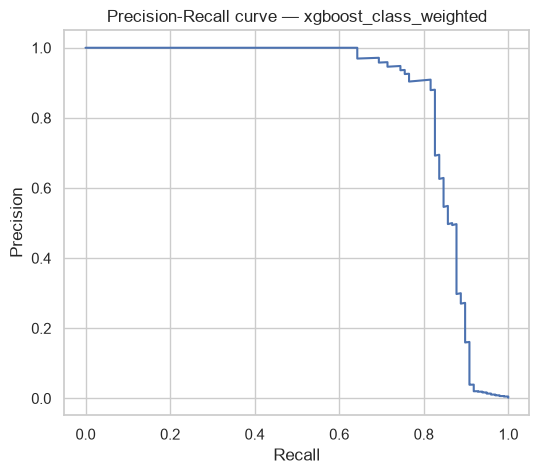

In [6]:
y_proba = winner.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — {winner_name}")
plt.show()

In [7]:
best_t = best_threshold_for_f1(winner, X_test, y_test)
final_metrics = evaluate(winner, X_test, y_test, threshold=best_t)
final_metrics

{'threshold': 0.9396722316741943,
 'pr_auc': 0.8534185266857303,
 'precision': 0.9090909090909091,
 'recall': 0.8163265306122449,
 'f1': 0.8602150537634409,
 'confusion_matrix': [[56856, 8], [18, 80]]}

## Confusion matrix at the chosen threshold

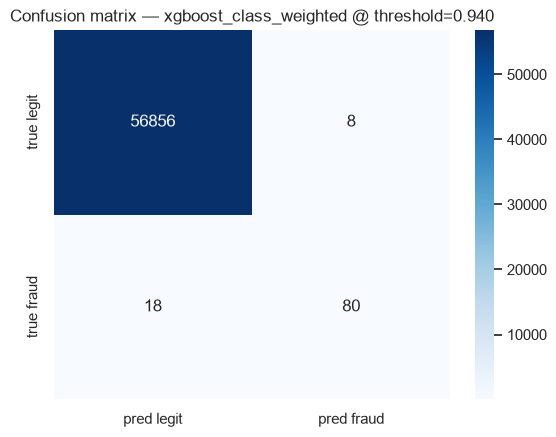

In [8]:
cm = final_metrics["confusion_matrix"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred legit", "pred fraud"],
            yticklabels=["true legit", "true fraud"])
plt.title(f"Confusion matrix — {winner_name} @ threshold={best_t:.3f}")
plt.show()

## Findings

- Winning model: **xgboost_class_weighted** (highest PR-AUC: 0.853 vs. 0.719 for class-weighted Logistic Regression and 0.724 for SMOTE + Logistic Regression — XGBoost is clearly ahead, the two Logistic Regression variants are within noise of each other).
- At threshold=0.5, XGBoost already beats both baselines on every metric: precision 0.626, recall 0.837, F1 0.716 (vs. F1 ~0.11 for both Logistic Regression variants, which trade almost all precision for recall at that threshold).
- Best-F1 threshold for XGBoost: **0.940** → precision 0.909, recall 0.816, F1 0.860. Confusion matrix on the 56,962-row test set: 8 false positives, 18 false negatives, 80/98 frauds caught.
- Confirms the `src/train.py` decision: class weighting (via `scale_pos_weight`) is a fine imbalance strategy for tree-based models here — SMOTE added no measurable benefit over plain class-weighted Logistic Regression, and both are well below XGBoost regardless of imbalance handling.
- `scripts/train_model.py` trains and saves this exact model (class-weighted XGBoost) as the shipped artifact in `models/fraud_model.joblib`, with metrics written to `reports/metrics.json`. The API in Phase 4 will expose the raw probability so callers can pick their own precision/recall tradeoff rather than baking in this notebook's threshold.